In [29]:
import numpy as np
import seaborn as sns


"""
    A 
"""


X = np.array([
    [  0.15,  -0.42],
    [ -1.31,   1.21],
    [  1.04,   0.46],
    [ -0.40,   1.63],
    [  1.82,  -1.16],
    [  0.30,   1.29],
    [ -1.20,   0.37],
    [  0.40,  -0.18],
    [  0.80,   0.13],
    [ -1.01,  -0.74],
    [  1.51,  -0.49],
    [ -3.54,   0.51],
    [ -2.91,   3.26],
    [  2.77,  -4.49],
    [  0.39,  -3.31],
    [ -1.69,   3.96],
    [ -4.38,  -2.15],
    [ -0.76,   4.61],
    [ -3.99,   1.22],
    [ -2.12,   2.80],
    [ -2.32,  -3.53],
    [ -2.70,   2.86],
])

y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

<Axes: >

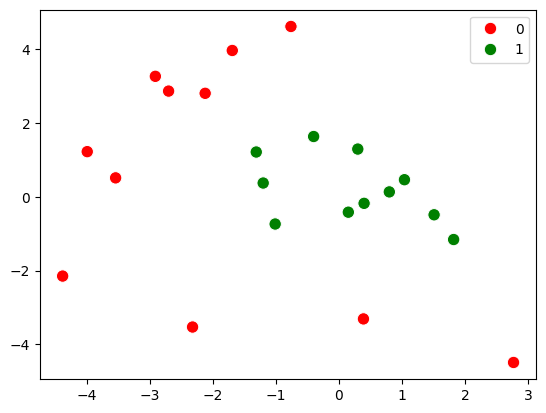

In [30]:
# scatter, colored by class
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette={1: 'green', 0: 'red'}, s=80)

In [31]:
def entropy(label):
    entropy_total = 0
    total_items = len(label)
    values, subset_items_k = np.unique(label, return_counts=True)
    
    for k in subset_items_k:
        probability_k = k / total_items
        entropy_total += probability_k*np.log2(probability_k)
    
    return -entropy_total


def information_gain(parent_labels, left_labels, right_labels):
    
    n_parent = len(parent_labels)
    
    weighted_left = (len(left_labels) / n_parent) * entropy(left_labels)
    weighted_right = (len(right_labels) / n_parent) * entropy(right_labels)
    
    return entropy(parent_labels) - (weighted_left + weighted_right)


def best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):
        # sorted unique values of this feature, then midpoints between them
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            mask = X[:, feature] <= threshold
            left_labels = y[mask]
            right_labels = y[~mask]

            # skip splits that put everything on one side
            if len(left_labels) == 0 or len(right_labels) == 0:
                continue

            gain = information_gain(y, left_labels, right_labels)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain
    

In [32]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, prediction=None):
        self.feature = feature          # which feature this node splits on
        self.threshold = threshold      # the threshold value for the split
        self.left = left                # left child Node (feature <= threshold)
        self.right = right              # right child Node (feature > threshold)
        self.prediction = prediction    # only set if this is a leaf

    def is_leaf(self):
        return self.prediction is not None


def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2):
    # stopping conditions -> become a leaf
    if len(np.unique(y)) == 1 or len(y) < min_samples_split or depth >= max_depth:
        majority_class = np.bincount(y).argmax()
        return Node(prediction=majority_class)

    feature, threshold, gain = best_split(X, y)

    # no split improves anything -> leaf
    if gain <= 0 or feature is None:
        majority_class = np.bincount(y).argmax()
        return Node(prediction=majority_class)

    # apply the split, recurse into both children
    mask = X[:, feature] <= threshold
    left_child = build_tree(X[mask], y[mask], depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X[~mask], y[~mask], depth + 1, max_depth, min_samples_split)

    return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)


def predict_one(node, x):
    # walk down the tree until reaching a leaf
    if node.is_leaf():
        return node.prediction
    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)


def predict(node, X):
    return np.array([predict_one(node, x) for x in X])